# ACTIVIDAD 8: REDES NEURONALES CONVOLUCIONALES - Clasificación de Imágenes Histopatológicas de Colon

---

En esta actividad, vamos a trabajar con Convolutional Neural Networks para resolver un problema de clasificación de imágenes médicas. En particular, vamos a clasificar imágenes histopatológicas de tejido de colon para detectar adenocarcinoma (cáncer) vs tejido benigno.

Como las CNN profundas son un tipo de modelo bastante avanzado y computacionalmente costoso, se recomienda hacer la práctica en Google Colaboratory con soporte para GPUs. En [este enlace](https://medium.com/deep-learning-turkey/google-colab-free-gpu-tutorial-e113627b9f5d) se explica cómo activar un entorno con GPUs.

El dataset a utilizar consiste en imágenes histopatológicas de tejido de colon que contienen dos clases:
- **colon_aca**: Adenocarcinoma de colon (tejido canceroso)
- **colon_n**: Tejido de colon benigno (normal)

El dataset puede ser descargado desde Kaggle:

[Dataset: Lung and Colon Cancer Histopathological Images](https://www.kaggle.com/datasets/andrewmvd/lung-and-colon-cancer-histopathological-images)

**Nota**: Solo utilizaremos las imágenes de la carpeta `colon_image_sets` para esta práctica, ya que nos enfocamos únicamente en la clasificación de tejido de colon.

## Carga de los datos

In [1]:
import cv2
import os
import numpy as np
import keras
from tensorflow import keras
import matplotlib.pyplot as plt
import glob
import tensorflow as tf
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [2]:
# Descargar el dataset desde Kaggle usando kagglehub
# Instalar kagglehub si no está instalado
!pip install -q kagglehub

import kagglehub

# Descargar el dataset de imágenes histopatológicas de Colon y Pulmón desde Kaggle
# Dataset: https://www.kaggle.com/datasets/andrewmvd/lung-and-colon-cancer-histopathological-images
print("Descargando dataset de imágenes histopatológicas de Colon y Pulmón desde Kaggle usando kagglehub...")
print("Esto puede tardar varios minutos dependiendo de tu conexión...")

try:
    # Descargar la última versión del dataset
    path = kagglehub.dataset_download("andrewmvd/lung-and-colon-cancer-histopathological-images")

    print(f"\n✅ Dataset descargado correctamente en: {path}")
    print(f"Contenido del directorio:")

    import os
    for item in os.listdir(path):
        item_path = os.path.join(path, item)
        if os.path.isdir(item_path):
            num_files = len([f for f in os.listdir(item_path) if os.path.isfile(os.path.join(item_path, f))])
            print(f"  📁 {item}/ ({num_files} archivos)")
        else:
            print(f"  📄 {item}")

except Exception as e:
    print(f"\n❌ Error al descargar el dataset: {e}")
    raise

Descargando dataset de imágenes histopatológicas de Colon y Pulmón desde Kaggle usando kagglehub...
Esto puede tardar varios minutos dependiendo de tu conexión...


100%|██████████| 1.76G/1.76G [00:18<00:00, 103MB/s]

Extracting files...



✅ Dataset descargado correctamente en: /root/.cache/kagglehub/datasets/andrewmvd/lung-and-colon-cancer-histopathological-images/versions/1
Contenido del directorio:
  📁 lung_colon_image_set/ (0 archivos)


In [3]:
# Esta variable contiene un mapeo de número de clase a tipo de tejido.
# Utilizamos las 2 clases del dataset de colon
MAP_CLASSES = {
    0: 'colon_aca',  # Adenocarcinoma de colon (cáncer)
    1: 'colon_n'     # Tejido de colon benigno (normal)
}

# Nombres descriptivos para visualización
CLASS_NAMES = {
    0: 'Adenocarcinoma',
    1: 'Benigno'
}

# Tamaño de las imágenes (las originales son 768x768, las redimensionamos)
IMG_SIZE = 128

In [4]:
def load_colon_dataset(dirname, map_classes, verbose=True):
    """Esta función carga los datos de imágenes histopatológicas de colon.

    Como las imágenes tienen tamaños distintos, utilizamos la librería opencv
    para hacer un resize y adaptarlas todas a tamaño IMG_SIZE x IMG_SIZE.

    Args:
        dirname: directorio completo del que leer los datos
        map_classes: variable de mapeo entre labels y tipo de tejido
        verbose: si es True, muestra información de las imágenes cargadas

    Returns:
        X, y: X es un array con todas las imágenes cargadas con tamaño
                IMG_SIZE x IMG_SIZE
              y es un array con las labels correspondientes a cada imagen
    """
    X_data = []
    y_data = []
    for label, tissue_type in map_classes.items():
        tissue_path = os.path.join(dirname, tissue_type)
        if not os.path.exists(tissue_path):
            if verbose:
                print(f"⚠️ Carpeta no encontrada: {tissue_path}")
            continue

        files = os.listdir(tissue_path)
        images = [file for file in files if file.endswith(("jpeg", "jpg", "png"))]
        if verbose:
            print(f"Leyendo {len(images)} imágenes de {tissue_type} ({CLASS_NAMES[label]})")

        for image_name in images:
            image = cv2.imread(os.path.join(tissue_path, image_name))
            if image is not None:
                # Convertir de BGR a RGB (opencv lee en BGR)
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                X_data.append(cv2.resize(image, (IMG_SIZE, IMG_SIZE)))
                y_data.append(label)

    return np.array(X_data), np.array(y_data)

In [5]:
# Configurar las rutas del dataset descargado con kagglehub
# La variable 'path' contiene la ubicación donde kagglehub descargó los datos

print("Configurando rutas del dataset de Colon...")

import os

if 'path' in locals():
    print(f"✅ Path del dataset: {path}")

    # Explorar la estructura del dataset descargado
    contents = os.listdir(path)
    print(f"\nContenido del dataset:")
    for item in contents:
        item_path = os.path.join(path, item)
        if os.path.isdir(item_path):
            sub_contents = os.listdir(item_path)
            print(f"  📁 {item}/ ({len(sub_contents)} elementos)")
            for sub_item in sub_contents:
                sub_path = os.path.join(item_path, sub_item)
                if os.path.isdir(sub_path):
                    files = [f for f in os.listdir(sub_path) if f.endswith(('.jpeg', '.jpg', '.png'))]
                    print(f"      📁 {sub_item}/ ({len(files)} imágenes)")
        else:
            print(f"  📄 {item}")

    # Buscar la carpeta colon_image_sets
    colon_path = None

    # El dataset tiene estructura: lung_colon_image_set/colon_image_sets/
    for item in contents:
        item_path = os.path.join(path, item)
        if os.path.isdir(item_path):
            # Buscar colon_image_sets dentro de cada carpeta
            if 'colon_image_sets' in os.listdir(item_path):
                colon_path = os.path.join(item_path, 'colon_image_sets')
                break
            elif item == 'colon_image_sets':
                colon_path = item_path
                break

    if colon_path is None:
        # Buscar de forma recursiva
        for root, dirs, files in os.walk(path):
            if 'colon_image_sets' in dirs:
                colon_path = os.path.join(root, 'colon_image_sets')
                break

    if colon_path and os.path.exists(colon_path):
        print(f"\n✅ Carpeta de colon encontrada: {colon_path}")

        # Verificar contenido de colon_image_sets
        colon_contents = os.listdir(colon_path)
        print(f"\nContenido de colon_image_sets:")
        for item in colon_contents:
            item_full_path = os.path.join(colon_path, item)
            if os.path.isdir(item_full_path):
                num_images = len([f for f in os.listdir(item_full_path) if f.endswith(('.jpeg', '.jpg', '.png'))])
                print(f"  📁 {item}/ ({num_images} imágenes)")

        DATASET_PATH = colon_path

        # Cargar los datos
        print("\n" + "="*60)
        print("Cargando imágenes histopatológicas de colon...")
        print("="*60)
        X, y = load_colon_dataset(DATASET_PATH, MAP_CLASSES)

        print(f"\n✅ Dataset cargado exitosamente!")
        print(f"   Total de imágenes: {len(X)}")
        print(f"   Forma de X: {X.shape}")
        print(f"   Clases únicas: {np.unique(y)}")
    else:
        print("❌ Error: No se encontró la carpeta colon_image_sets")
        print("   Estructura del dataset puede ser diferente a la esperada.")
else:
    print("❌ Error: La variable 'path' no está definida.")
    print("   Ejecuta primero la celda de descarga del dataset.")

Configurando rutas del dataset de Colon...
✅ Path del dataset: /root/.cache/kagglehub/datasets/andrewmvd/lung-and-colon-cancer-histopathological-images/versions/1

Contenido del dataset:
  📁 lung_colon_image_set/ (2 elementos)
      📁 lung_image_sets/ (0 imágenes)
      📁 colon_image_sets/ (0 imágenes)

✅ Carpeta de colon encontrada: /root/.cache/kagglehub/datasets/andrewmvd/lung-and-colon-cancer-histopathological-images/versions/1/lung_colon_image_set/colon_image_sets

Contenido de colon_image_sets:
  📁 colon_n/ (5000 imágenes)
  📁 colon_aca/ (5000 imágenes)

Cargando imágenes histopatológicas de colon...
Leyendo 5000 imágenes de colon_aca (Adenocarcinoma)
Leyendo 5000 imágenes de colon_n (Benigno)

✅ Dataset cargado exitosamente!
   Total de imágenes: 10000
   Forma de X: (10000, 128, 128, 3)
   Clases únicas: [0 1]


In [6]:
# Vamos a barajar aleatoriamente los datos. Esto es importante ya que si no
# lo hacemos y, por ejemplo, cogemos el 20% de los datos finales como validation
# set, estaremos utilizando solo un pequeño número de personajes, ya que
# las imágenes se leen secuencialmente personaje a personaje.
perm = np.random.permutation(len(X))
X, y = X[perm], y[perm]

Visualizando muestras del dataset de colon...


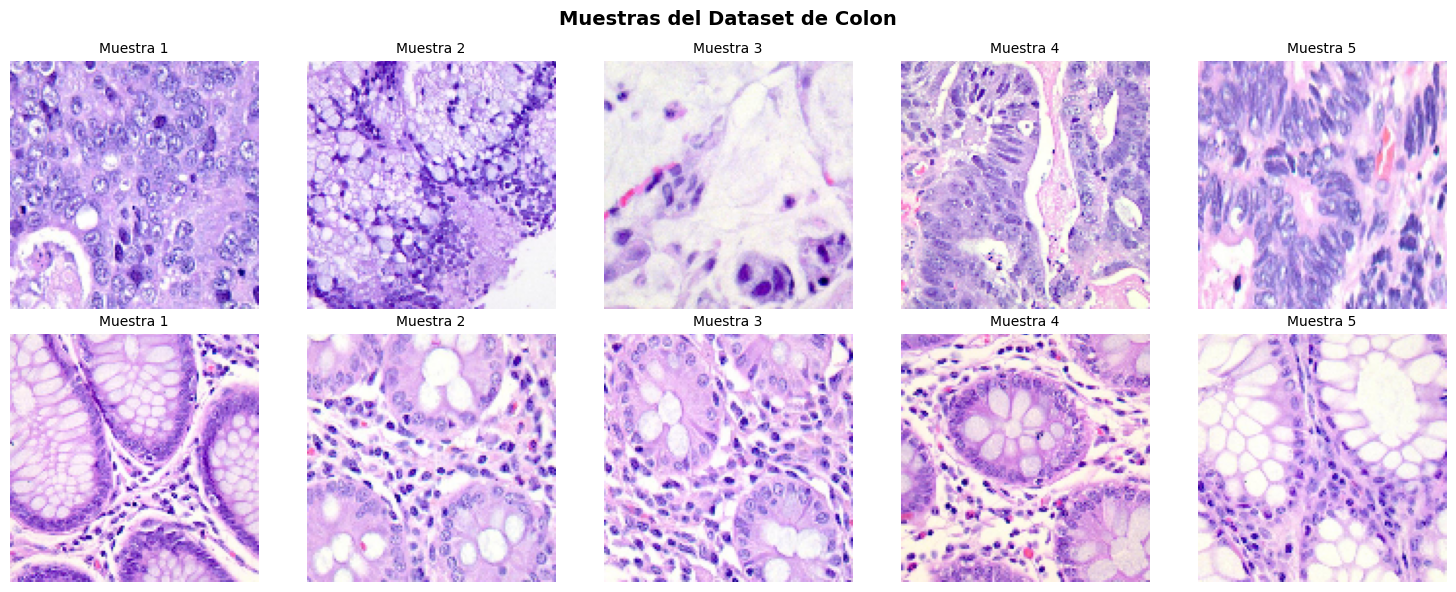

In [7]:
# Visualizar algunas imágenes del dataset
print("Visualizando muestras del dataset de colon...")

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, label in enumerate([0, 1]):  # 0: Adenocarcinoma, 1: Benigno
    indices = np.where(y == label)[0]
    for j in range(5):
        ax = axes[i, j]
        ax.imshow(X[indices[j]])
        ax.axis('off')
        if j == 0:
            ax.set_ylabel(CLASS_NAMES[label], fontsize=12, rotation=0, ha='right', va='center')
        ax.set_title(f'Muestra {j+1}', fontsize=10)

plt.suptitle('Muestras del Dataset de Colon', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Ejercicio

Utilizando Convolutional Neural Networks con Keras, entrenar un clasificador que sea capaz de distinguir entre imágenes histopatológicas de tejido de colon con adenocarcinoma (cáncer) y tejido benigno con una accuracy en el dataset de test de, al menos, **90%**. Redactar un informe analizando varias de las alternativas probadas y los resultados obtenidos.

A continuación se detallan una serie de aspectos orientativos que podrían ser analizados en vuestro informe:

*   Análisis de los datos a utilizar (distribución de clases, características de las imágenes).
*   Análisis de resultados, obtención de métricas de *precision* y *recall* por clase y análisis de qué clase obtiene mejores o peores resultados.
*   Análisis visual de los errores de la red. ¿Qué tipo de imágenes dan más problemas a nuestro modelo?
*   Comparación de modelos CNNs con un modelo de Fully Connected para este problema.
*   Utilización de distintas arquitecturas CNNs, comentando aspectos como su profundidad, hiperparámetros utilizados, optimizador, uso de técnicas de regularización, *batch normalization*, etc.
*   Utilización de *data augmentation* para mejorar la generalización del modelo.

Notas:
* Recuerda partir los datos en training/validation/test para tener una buena estimación de los valores que nuestro modelo tendrá en los datos de test, así como comprobar que no estamos cayendo en overfitting. Una posible partición puede ser 70/15/15 o 80/10/10.
* Las imágenes **no están normalizadas**. Hay que normalizarlas dividiendo por 255.
* Este es un problema de clasificación binaria (cáncer vs benigno), lo que tiene implicaciones importantes en medicina.

In [8]:
# Importar librerías adicionales necesarias
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, precision_recall_fscore_support
import seaborn as sns
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print("Librerías importadas correctamente")

Librerías importadas correctamente


ANÁLISIS EXPLORATORIO DEL DATASET DE COLON

Total de imágenes: 10000
Tamaño de cada imagen: 128x128 píxeles
Número de canales: 3 (RGB)
Número de clases: 2
Rango de valores de píxeles: [0, 255]

--- Distribución de Clases ---
         Clase    Código  Cantidad  Porcentaje
Adenocarcinoma colon_aca      5000        50.0
       Benigno   colon_n      5000        50.0


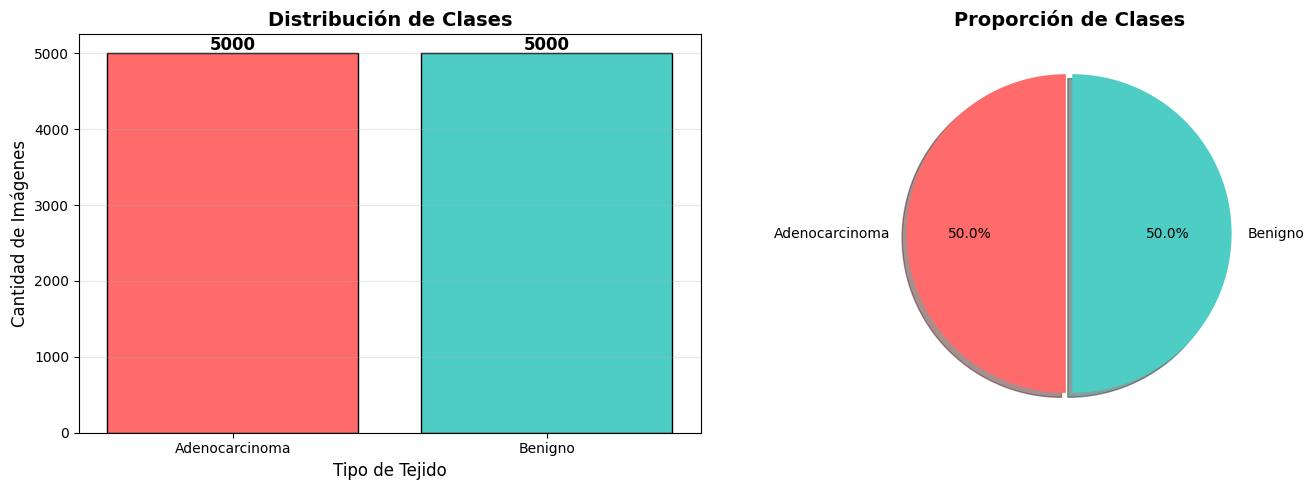


--- Muestras de cada clase ---


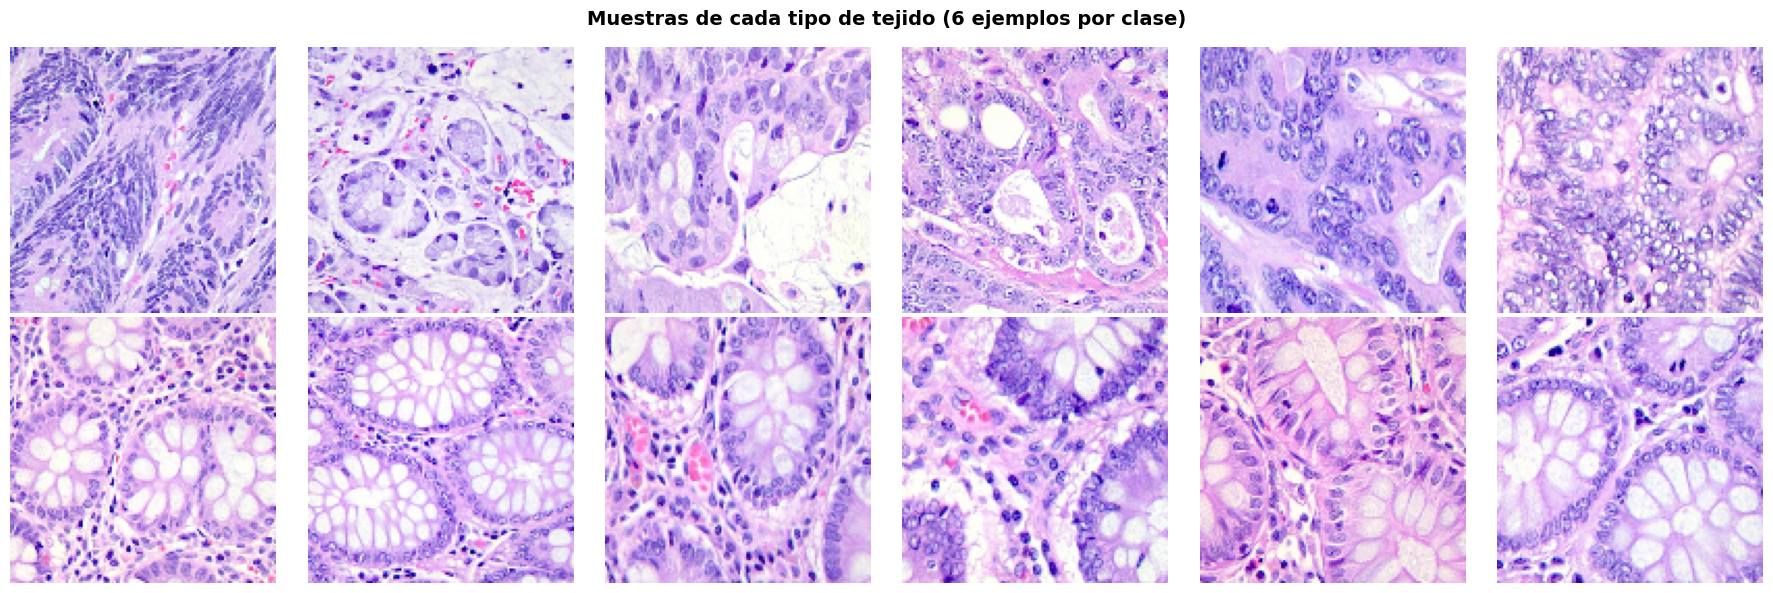

In [9]:
# ANÁLISIS EXPLORATORIO DE DATOS
print("="*80)
print("ANÁLISIS EXPLORATORIO DEL DATASET DE COLON")
print("="*80 + "\n")

# Información básica
print(f"Total de imágenes: {len(X)}")
print(f"Tamaño de cada imagen: {IMG_SIZE}x{IMG_SIZE} píxeles")
print(f"Número de canales: {X.shape[-1]} (RGB)")
print(f"Número de clases: {len(MAP_CLASSES)}")
print(f"Rango de valores de píxeles: [{X.min()}, {X.max()}]")

# Distribución de clases
print("\n--- Distribución de Clases ---")
unique, counts = np.unique(y, return_counts=True)
df_dist = pd.DataFrame({
    'Clase': [CLASS_NAMES[i] for i in unique],
    'Código': [MAP_CLASSES[i] for i in unique],
    'Cantidad': counts,
    'Porcentaje': (counts / len(y) * 100).round(2)
})
print(df_dist.to_string(index=False))

# Visualización de la distribución
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
colors = ['#FF6B6B', '#4ECDC4']
ax1.bar([CLASS_NAMES[i] for i in unique], counts, color=colors, edgecolor='black')
ax1.set_xlabel('Tipo de Tejido', fontsize=12)
ax1.set_ylabel('Cantidad de Imágenes', fontsize=12)
ax1.set_title('Distribución de Clases', fontsize=14, fontweight='bold')
for i, (v, c) in enumerate(zip(counts, counts)):
    ax1.text(i, v + 50, str(c), ha='center', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Gráfico circular
ax2.pie(counts, labels=[CLASS_NAMES[i] for i in unique], autopct='%1.1f%%',
        colors=colors, explode=[0.02, 0.02], shadow=True, startangle=90)
ax2.set_title('Proporción de Clases', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Visualizar muestras de cada clase
print("\n--- Muestras de cada clase ---")
fig, axes = plt.subplots(2, 6, figsize=(18, 6))

for idx, label in enumerate([0, 1]):
    indices = np.where(y == label)[0]
    np.random.shuffle(indices)
    for i in range(6):
        ax = axes[idx, i]
        ax.imshow(X[indices[i]])
        ax.axis('off')
        if i == 0:
            ax.set_ylabel(CLASS_NAMES[label], fontsize=12, rotation=0, ha='right', va='center')

plt.suptitle('Muestras de cada tipo de tejido (6 ejemplos por clase)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*80)

In [10]:
# PREPARACIÓN DE DATOS
print("="*80)
print("PREPARACIÓN DE DATOS")
print("="*80 + "\n")

# Normalizar las imágenes (0-255 -> 0-1)
print("Normalizando imágenes...")
X_normalized = X.astype('float32') / 255.0

print(f"Rango normalizado: [{X_normalized.min():.2f}, {X_normalized.max():.2f}]")

# Convertir etiquetas a one-hot encoding para clasificación binaria
print("\nConvirtiendo etiquetas a one-hot encoding...")
y_categorical = keras.utils.to_categorical(y, len(MAP_CLASSES))

print(f"Forma de y_categorical: {y_categorical.shape}")

# Dividir datos en training, validation y test (70/15/15)
print("\nDividiendo datos en Training, Validation y Test (70/15/15)...")
from sklearn.model_selection import train_test_split

# Primera división: separar test (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_normalized, y_categorical,
    test_size=0.15,
    random_state=SEED,
    stratify=y
)

# Segunda división: separar validation del resto (15% del total = ~17.6% del temp)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.176,
    random_state=SEED,
    stratify=np.argmax(y_temp, axis=1)
)

# También necesitamos las etiquetas sin one-hot para algunas métricas
y_test_labels = np.argmax(y_test, axis=1)

print(f"\n📊 Resumen de la división de datos:")
print(f"   Conjunto de Training: {X_train.shape[0]} imágenes ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"   Conjunto de Validation: {X_val.shape[0]} imágenes ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"   Conjunto de Test: {X_test.shape[0]} imágenes ({X_test.shape[0]/len(X)*100:.1f}%)")

# Verificar distribución de clases en cada conjunto
print("\n📊 Distribución de clases por conjunto:")
for name, labels in [("Training", np.argmax(y_train, axis=1)),
                      ("Validation", np.argmax(y_val, axis=1)),
                      ("Test", y_test_labels)]:
    unique, counts = np.unique(labels, return_counts=True)
    print(f"   {name}: {CLASS_NAMES[0]}={counts[0]}, {CLASS_NAMES[1]}={counts[1]}")

print("\n" + "="*80)

PREPARACIÓN DE DATOS

Normalizando imágenes...
Rango normalizado: [0.00, 1.00]

Convirtiendo etiquetas a one-hot encoding...
Forma de y_categorical: (10000, 2)

Dividiendo datos en Training, Validation y Test (70/15/15)...

📊 Resumen de la división de datos:
   Conjunto de Training: 7004 imágenes (70.0%)
   Conjunto de Validation: 1496 imágenes (15.0%)
   Conjunto de Test: 1500 imágenes (15.0%)

📊 Distribución de clases por conjunto:
   Training: Adenocarcinoma=3502, Benigno=3502
   Validation: Adenocarcinoma=748, Benigno=748
   Test: Adenocarcinoma=750, Benigno=750



In [11]:
# CONSTRUCCIÓN DEL MODELO CNN
print("="*80)
print("CONSTRUCCIÓN DEL MODELO CNN PARA CLASIFICACIÓN DE TEJIDO DE COLON")
print("="*80 + "\n")

print("Arquitectura: CNN con 3 bloques convolucionales + Batch Normalization + Dropout")
print(f"Input shape: {IMG_SIZE}x{IMG_SIZE}x3 (RGB)")
print(f"Output: {len(MAP_CLASSES)} clases (Adenocarcinoma vs Benigno)")
print("="*80 + "\n")

# Construir modelo CNN
model = keras.models.Sequential([
    # Primer bloque convolucional
    keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                        input_shape=(IMG_SIZE, IMG_SIZE, 3), name='conv1'),
    keras.layers.BatchNormalization(name='bn1'),
    keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='conv1_2'),
    keras.layers.BatchNormalization(name='bn1_2'),
    keras.layers.MaxPooling2D((2, 2), name='pool1'),
    keras.layers.Dropout(0.25, name='dropout1'),

    # Segundo bloque convolucional
    keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2'),
    keras.layers.BatchNormalization(name='bn2'),
    keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2_2'),
    keras.layers.BatchNormalization(name='bn2_2'),
    keras.layers.MaxPooling2D((2, 2), name='pool2'),
    keras.layers.Dropout(0.25, name='dropout2'),

    # Tercer bloque convolucional
    keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='conv3'),
    keras.layers.BatchNormalization(name='bn3'),
    keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='conv3_2'),
    keras.layers.BatchNormalization(name='bn3_2'),
    keras.layers.MaxPooling2D((2, 2), name='pool3'),
    keras.layers.Dropout(0.25, name='dropout3'),

    # Cuarto bloque convolucional (adicional para imágenes más grandes)
    keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same', name='conv4'),
    keras.layers.BatchNormalization(name='bn4'),
    keras.layers.MaxPooling2D((2, 2), name='pool4'),
    keras.layers.Dropout(0.25, name='dropout4'),

    # Capas densas
    keras.layers.Flatten(name='flatten'),
    keras.layers.Dense(256, activation='relu', name='dense1'),
    keras.layers.BatchNormalization(name='bn_dense1'),
    keras.layers.Dropout(0.5, name='dropout5'),
    keras.layers.Dense(128, activation='relu', name='dense2'),
    keras.layers.BatchNormalization(name='bn_dense2'),
    keras.layers.Dropout(0.5, name='dropout6'),
    keras.layers.Dense(len(MAP_CLASSES), activation='softmax', name='output')
])

# Compilar el modelo
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Mostrar resumen del modelo
print("\n--- Resumen del Modelo ---")
model.summary()

print("\n" + "="*80)

CONSTRUCCIÓN DEL MODELO CNN PARA CLASIFICACIÓN DE TEJIDO DE COLON

Arquitectura: CNN con 3 bloques convolucionales + Batch Normalization + Dropout
Input shape: 128x128x3 (RGB)
Output: 2 clases (Adenocarcinoma vs Benigno)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Resumen del Modelo ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 128, 128, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_2 (Conv2D)                │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1_2 (BatchNormalization)      │ (None, 128, 128, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 64, 64, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_2 (Conv2D)                │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2_2 (BatchNormalization)      │ (None, 64, 64, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 32, 32, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_2 (Conv2D)                │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3_2 (BatchNormalization)      │ (None, 32, 32, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout3 (Dropout)              │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn4 (BatchNormalization)        │ (None, 16, 16, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool4 (MaxPooling2D)            │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout4 (Dropout)              │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dense1 (BatchNormalization)  │ (None, 256)            │         1,02

 Total params: 4,814,242 (18.36 MB)

 Trainable params: 4,812,066 (18.36 MB)

 Non-trainable params: 2,176 (8.50 KB)

In [12]:
# ENTRENAMIENTO DEL MODELO
print("="*80)
print("ENTRENAMIENTO DEL MODELO CNN")
print("="*80 + "\n")

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

print("Callbacks configurados:")
print("  - EarlyStopping: patience=15, monitor='val_loss'")
print("  - ReduceLROnPlateau: factor=0.5, patience=5")
print("\nIniciando entrenamiento...\n")

# Entrenar el modelo
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print("\n" + "="*80)
print("ENTRENAMIENTO COMPLETADO")
print("="*80)

ENTRENAMIENTO DEL MODELO CNN

Callbacks configurados:
  - EarlyStopping: patience=15, monitor='val_loss'
  - ReduceLROnPlateau: factor=0.5, patience=5

Iniciando entrenamiento...

Epoch 1/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 51s 136ms/step - accuracy: 0.8357 - loss: 0.4199 - val_accuracy: 0.5194 - val_loss: 1.7595 - learning_rate: 0.0010
Epoch 2/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 49s 56ms/step - accuracy: 0.9736 - loss: 0.0695 - val_accuracy: 0.5000 - val_loss: 7.3903 - learning_rate: 0.0010
Epoch 3/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 12s 55ms/step - accuracy: 0.9780 - loss: 0.0580 - val_accuracy: 0.5053 - val_loss: 4.1818 - learning_rate: 0.0010
Epoch 4/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 12s 56ms/step - accuracy: 0.9884 - loss: 0.0281 - val_accuracy: 0.9646 - val_loss: 0.1067 - learning_rate: 0.0010
Epoch 5/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 12s 57ms/step - accuracy: 0.9900 - loss: 0.0266 - val_accuracy: 0.5000 - val_loss: 6.3797 - learning_rate: 0.0010
Epoch 6/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 13s 57ms/

ANÁLISIS DE CURVAS DE APRENDIZAJE



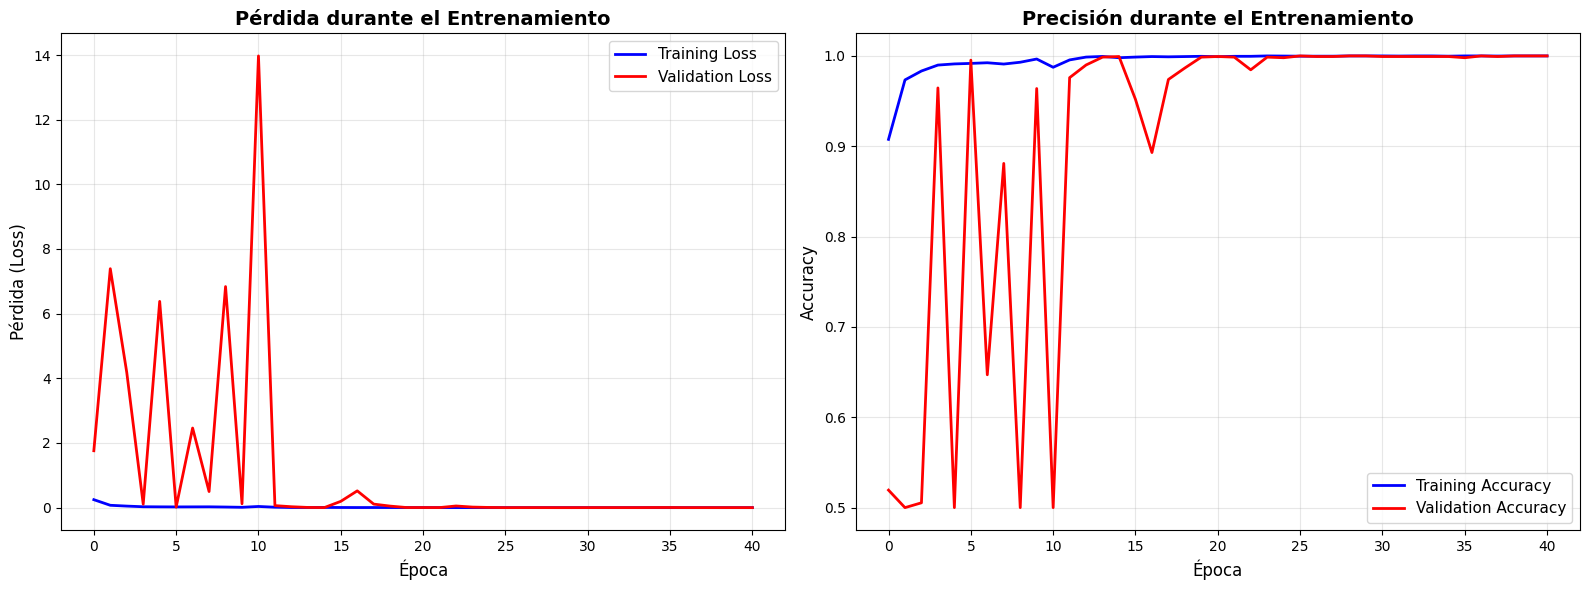


Épocas entrenadas: 41
Mejor época: 26
Mejor val_loss: 0.0000
Mejor val_accuracy: 1.0000

Accuracy final Training: 1.0000
Accuracy final Validation: 1.0000
Diferencia: 0.0000
✅ Modelo bien generalizado



In [13]:
# VISUALIZACIÓN DE CURVAS DE APRENDIZAJE
print("="*80)
print("ANÁLISIS DE CURVAS DE APRENDIZAJE")
print("="*80 + "\n")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de pérdida
ax1.plot(history.history['loss'], label='Training Loss', linewidth=2, color='blue')
ax1.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, color='red')
ax1.set_title('Pérdida durante el Entrenamiento', fontsize=14, fontweight='bold')
ax1.set_xlabel('Época', fontsize=12)
ax1.set_ylabel('Pérdida (Loss)', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Gráfico de accuracy
ax2.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2, color='blue')
ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, color='red')
ax2.set_title('Precisión durante el Entrenamiento', fontsize=14, fontweight='bold')
ax2.set_xlabel('Época', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Información de las curvas
epochs_trained = len(history.history['loss'])
best_epoch = np.argmin(history.history['val_loss'])
best_val_loss = history.history['val_loss'][best_epoch]
best_val_acc = history.history['val_accuracy'][best_epoch]

print(f"\nÉpocas entrenadas: {epochs_trained}")
print(f"Mejor época: {best_epoch + 1}")
print(f"Mejor val_loss: {best_val_loss:.4f}")
print(f"Mejor val_accuracy: {best_val_acc:.4f}")

# Análisis de overfitting
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
diff_acc = final_train_acc - final_val_acc

print(f"\nAccuracy final Training: {final_train_acc:.4f}")
print(f"Accuracy final Validation: {final_val_acc:.4f}")
print(f"Diferencia: {diff_acc:.4f}")

if diff_acc > 0.1:
    print("⚠️ ADVERTENCIA: Posible overfitting detectado (diferencia > 10%)")
elif diff_acc > 0.05:
    print("⚠️ Ligero overfitting (diferencia > 5%)")
else:
    print("✅ Modelo bien generalizado")

print("\n" + "="*80)

In [14]:
# EVALUACIÓN EN CONJUNTO DE TEST
print("="*80)
print("EVALUACIÓN EN CONJUNTO DE TEST")
print("="*80 + "\n")

# Evaluar el modelo en el conjunto de test
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"Pérdida en Test: {test_loss:.4f}")
print(f"Accuracy en Test: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Verificar si cumple el objetivo
objetivo = 0.90
if test_accuracy >= objetivo:
    print(f"\n✅ ¡OBJETIVO CUMPLIDO! Accuracy >= 90%")
    print(f"   Superación del objetivo: +{(test_accuracy - objetivo)*100:.2f}%")
else:
    print(f"\n❌ Objetivo no alcanzado. Faltan {(objetivo - test_accuracy)*100:.2f}% para llegar al 90%")

# Realizar predicciones
print("\nRealizando predicciones en el conjunto de test...")
y_pred_proba = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

print(f"Predicciones realizadas: {len(y_pred)}")
print("\n" + "="*80)

EVALUACIÓN EN CONJUNTO DE TEST

Pérdida en Test: 0.0015
Accuracy en Test: 0.9993 (99.93%)

✅ ¡OBJETIVO CUMPLIDO! Accuracy >= 90%
   Superación del objetivo: +9.93%

Realizando predicciones en el conjunto de test...
Predicciones realizadas: 1500



In [15]:
# MÉTRICAS DETALLADAS
print("="*80)
print("MÉTRICAS DETALLADAS DE CLASIFICACIÓN")
print("="*80 + "\n")

# Calcular métricas globales
accuracy = accuracy_score(y_test_labels, y_pred)
precision_macro = precision_score(y_test_labels, y_pred, average='macro', zero_division=0)
recall_macro = recall_score(y_test_labels, y_pred, average='macro', zero_division=0)
f1_macro = f1_score(y_test_labels, y_pred, average='macro', zero_division=0)

print("--- Métricas Globales ---")
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision (macro): {precision_macro:.4f}")
print(f"Recall (macro): {recall_macro:.4f}")
print(f"F1-Score (macro): {f1_macro:.4f}")

# Reporte de clasificación completo
print("\n--- Reporte de Clasificación por Clase ---")
class_names_list = [CLASS_NAMES[i] for i in range(len(MAP_CLASSES))]
print(classification_report(y_test_labels, y_pred, target_names=class_names_list, zero_division=0))

# Métricas por clase
print("\n--- Análisis Detallado por Tipo de Tejido ---")
precision_per_class, recall_per_class, f1_per_class, support = precision_recall_fscore_support(
    y_test_labels, y_pred, average=None, zero_division=0
)

df_metricas = pd.DataFrame({
    'Tipo de Tejido': class_names_list,
    'Precision': precision_per_class,
    'Recall': recall_per_class,
    'F1-Score': f1_per_class,
    'Muestras': support
})

df_metricas = df_metricas.sort_values('F1-Score', ascending=False)
print(df_metricas.to_string(index=False))

# Análisis específico para clasificación médica
print("\n" + "="*80)
print("ANÁLISIS ESPECÍFICO PARA DIAGNÓSTICO MÉDICO")
print("="*80)

# Sensibilidad (Recall para clase positiva - Adenocarcinoma)
sensibilidad = recall_per_class[0]  # Clase 0 = Adenocarcinoma
especificidad = recall_per_class[1]  # Clase 1 = Benigno (TN / (TN + FP))

print(f"\n🔬 Sensibilidad (Recall Adenocarcinoma): {sensibilidad:.4f} ({sensibilidad*100:.2f}%)")
print(f"   → Capacidad de detectar casos de cáncer correctamente")
print(f"\n🔬 Especificidad (Recall Benigno): {especificidad:.4f} ({especificidad*100:.2f}%)")
print(f"   → Capacidad de identificar tejido sano correctamente")

# Valor Predictivo Positivo y Negativo
vpn = precision_per_class[0]  # Precisión para Adenocarcinoma
vpp = precision_per_class[1]  # Precisión para Benigno

print(f"\n📊 Valor Predictivo Positivo (Precisión Adenocarcinoma): {vpn:.4f}")
print(f"📊 Valor Predictivo Negativo (Precisión Benigno): {vpp:.4f}")

print("\n" + "="*80)

MÉTRICAS DETALLADAS DE CLASIFICACIÓN

--- Métricas Globales ---
Accuracy: 0.9993 (99.93%)
Precision (macro): 0.9993
Recall (macro): 0.9993
F1-Score (macro): 0.9993

--- Reporte de Clasificación por Clase ---
                precision    recall  f1-score   support

Adenocarcinoma       1.00      1.00      1.00       750
       Benigno       1.00      1.00      1.00       750

      accuracy                           1.00      1500
     macro avg       1.00      1.00      1.00      1500
  weighted avg       1.00      1.00      1.00      1500


--- Análisis Detallado por Tipo de Tejido ---
Tipo de Tejido  Precision   Recall  F1-Score  Muestras
Adenocarcinoma   0.998668 1.000000  0.999334       750
       Benigno   1.000000 0.998667  0.999333       750

ANÁLISIS ESPECÍFICO PARA DIAGNÓSTICO MÉDICO

🔬 Sensibilidad (Recall Adenocarcinoma): 1.0000 (100.00%)
   → Capacidad de detectar casos de cáncer correctamente

🔬 Especificidad (Recall Benigno): 0.9987 (99.87%)
   → Capacidad de identificar 

MATRIZ DE CONFUSIÓN



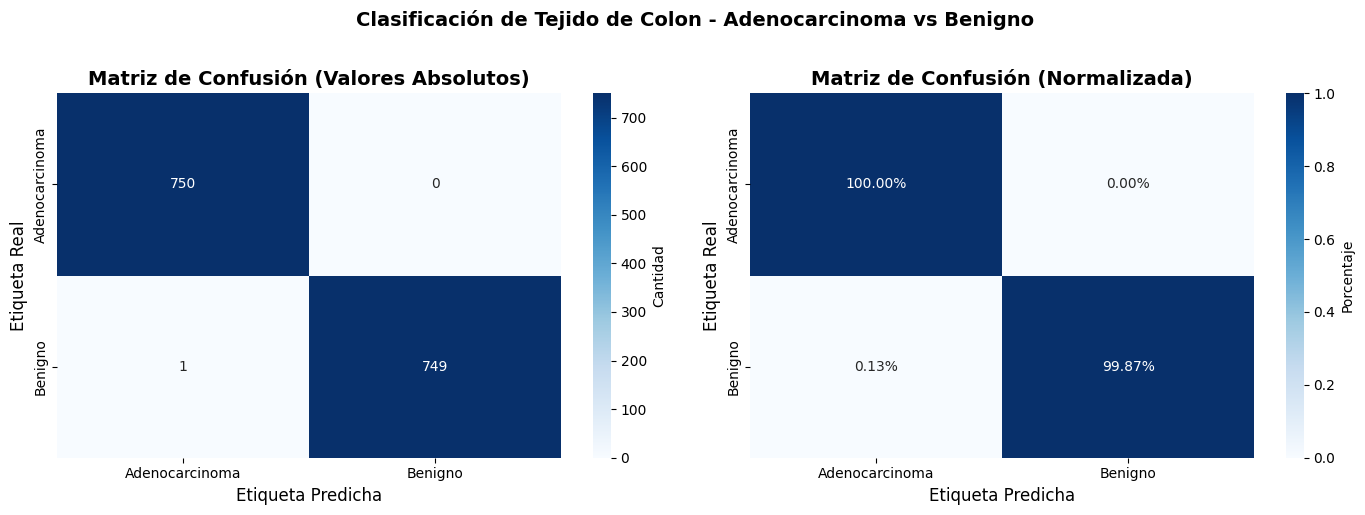


--- Análisis de la Matriz de Confusión ---

📊 Desglose de predicciones:
   Verdaderos Positivos (TP - Adenocarcinoma correcto): 749
   Verdaderos Negativos (TN - Benigno correcto): 750
   Falsos Positivos (FP - Benigno predicho como Adenocarcinoma): 0
   Falsos Negativos (FN - Adenocarcinoma predicho como Benigno): 1

⚠️ ANÁLISIS CLÍNICO:
   - Falsos Negativos (1): Casos de cáncer NO detectados (CRÍTICO)
   - Falsos Positivos (0): Casos benignos clasificados como cáncer

   ⚠️ ADVERTENCIA: Hay 1 casos de cáncer no detectados.
      En un contexto clínico, esto podría significar pacientes sin tratamiento.



In [16]:
# MATRIZ DE CONFUSIÓN
print("="*80)
print("MATRIZ DE CONFUSIÓN")
print("="*80 + "\n")

# Calcular matriz de confusión
cm = confusion_matrix(y_test_labels, y_pred)

# Visualización de la matriz de confusión
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión con valores absolutos
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names_list,
            yticklabels=class_names_list,
            cbar_kws={'label': 'Cantidad'},
            ax=ax1)
ax1.set_title('Matriz de Confusión (Valores Absolutos)',
          fontsize=14, fontweight='bold')
ax1.set_ylabel('Etiqueta Real', fontsize=12)
ax1.set_xlabel('Etiqueta Predicha', fontsize=12)

# Matriz de confusión normalizada
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=class_names_list,
            yticklabels=class_names_list,
            cbar_kws={'label': 'Porcentaje'},
            ax=ax2)
ax2.set_title('Matriz de Confusión (Normalizada)',
          fontsize=14, fontweight='bold')
ax2.set_ylabel('Etiqueta Real', fontsize=12)
ax2.set_xlabel('Etiqueta Predicha', fontsize=12)

plt.suptitle('Clasificación de Tejido de Colon - Adenocarcinoma vs Benigno',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Análisis de la matriz de confusión
print("\n--- Análisis de la Matriz de Confusión ---")
tn, fp, fn, tp = cm.ravel()

print(f"\n📊 Desglose de predicciones:")
print(f"   Verdaderos Positivos (TP - Adenocarcinoma correcto): {tp}")
print(f"   Verdaderos Negativos (TN - Benigno correcto): {tn}")
print(f"   Falsos Positivos (FP - Benigno predicho como Adenocarcinoma): {fp}")
print(f"   Falsos Negativos (FN - Adenocarcinoma predicho como Benigno): {fn}")

print(f"\n⚠️ ANÁLISIS CLÍNICO:")
print(f"   - Falsos Negativos ({fn}): Casos de cáncer NO detectados (CRÍTICO)")
print(f"   - Falsos Positivos ({fp}): Casos benignos clasificados como cáncer")

if fn > 0:
    print(f"\n   ⚠️ ADVERTENCIA: Hay {fn} casos de cáncer no detectados.")
    print(f"      En un contexto clínico, esto podría significar pacientes sin tratamiento.")
else:
    print(f"\n   ✅ Excelente: No hay falsos negativos (todos los casos de cáncer detectados)")

print("\n" + "="*80)

VISUALIZACIÓN DE MÉTRICAS POR CLASE



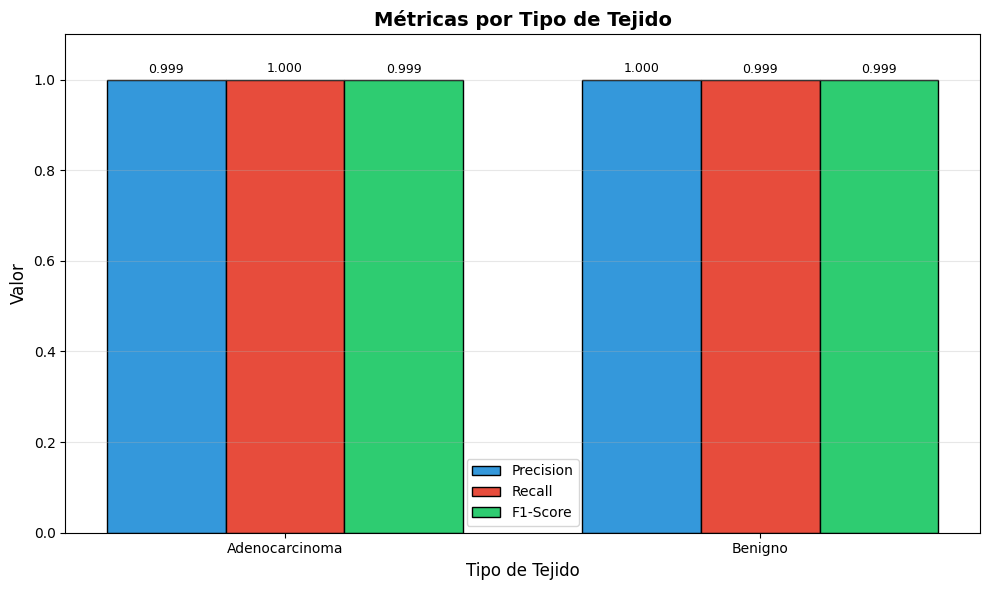


--- Comparación de Métricas Promedio ---


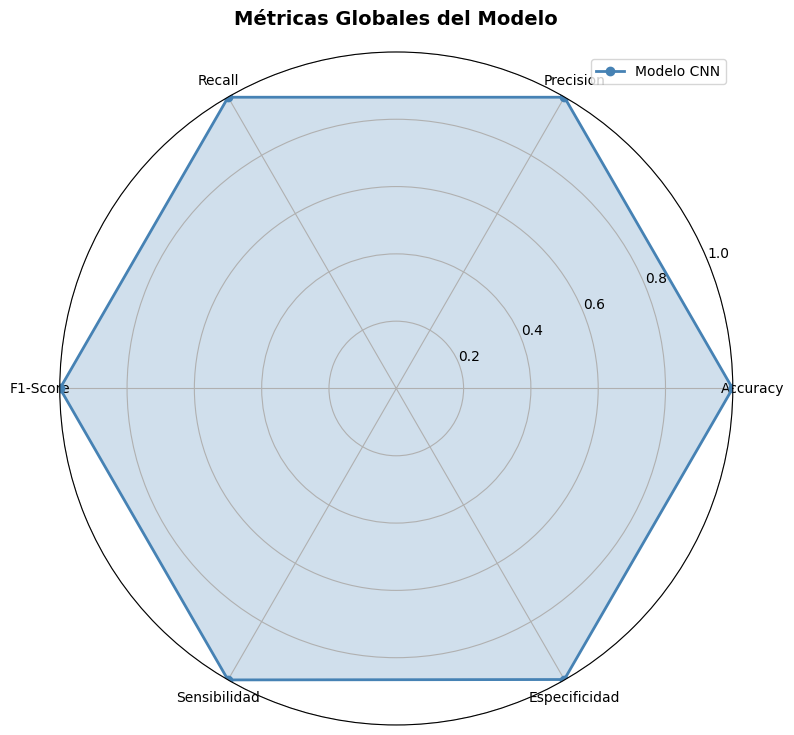

In [17]:
# VISUALIZACIÓN DE MÉTRICAS POR CLASE
print("="*80)
print("VISUALIZACIÓN DE MÉTRICAS POR CLASE")
print("="*80 + "\n")

# Crear gráfico de barras comparativo
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(class_names_list))
width = 0.25

bars1 = ax.bar(x - width, precision_per_class, width, label='Precision', color='#3498db', edgecolor='black')
bars2 = ax.bar(x, recall_per_class, width, label='Recall', color='#e74c3c', edgecolor='black')
bars3 = ax.bar(x + width, f1_per_class, width, label='F1-Score', color='#2ecc71', edgecolor='black')

ax.set_xlabel('Tipo de Tejido', fontsize=12)
ax.set_ylabel('Valor', fontsize=12)
ax.set_title('Métricas por Tipo de Tejido', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(class_names_list)
ax.legend()
ax.set_ylim([0, 1.1])
ax.grid(axis='y', alpha=0.3)

# Añadir valores encima de las barras
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Gráfico de radar para comparar métricas promedio
print("\n--- Comparación de Métricas Promedio ---")
metricas_promedio = {
    'Accuracy': accuracy,
    'Precision': precision_macro,
    'Recall': recall_macro,
    'F1-Score': f1_macro,
    'Sensibilidad': sensibilidad,
    'Especificidad': especificidad
}

labels = list(metricas_promedio.keys())
values = list(metricas_promedio.values())

angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
values_plot = values + values[:1]
angles_plot = angles + angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='polar'))
ax.plot(angles_plot, values_plot, 'o-', linewidth=2, color='steelblue', label='Modelo CNN')
ax.fill(angles_plot, values_plot, alpha=0.25, color='steelblue')
ax.set_xticks(angles)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'])
ax.grid(True)
ax.set_title('Métricas Globales del Modelo', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

print("\n" + "="*80)

ANÁLISIS VISUAL DE PREDICCIONES



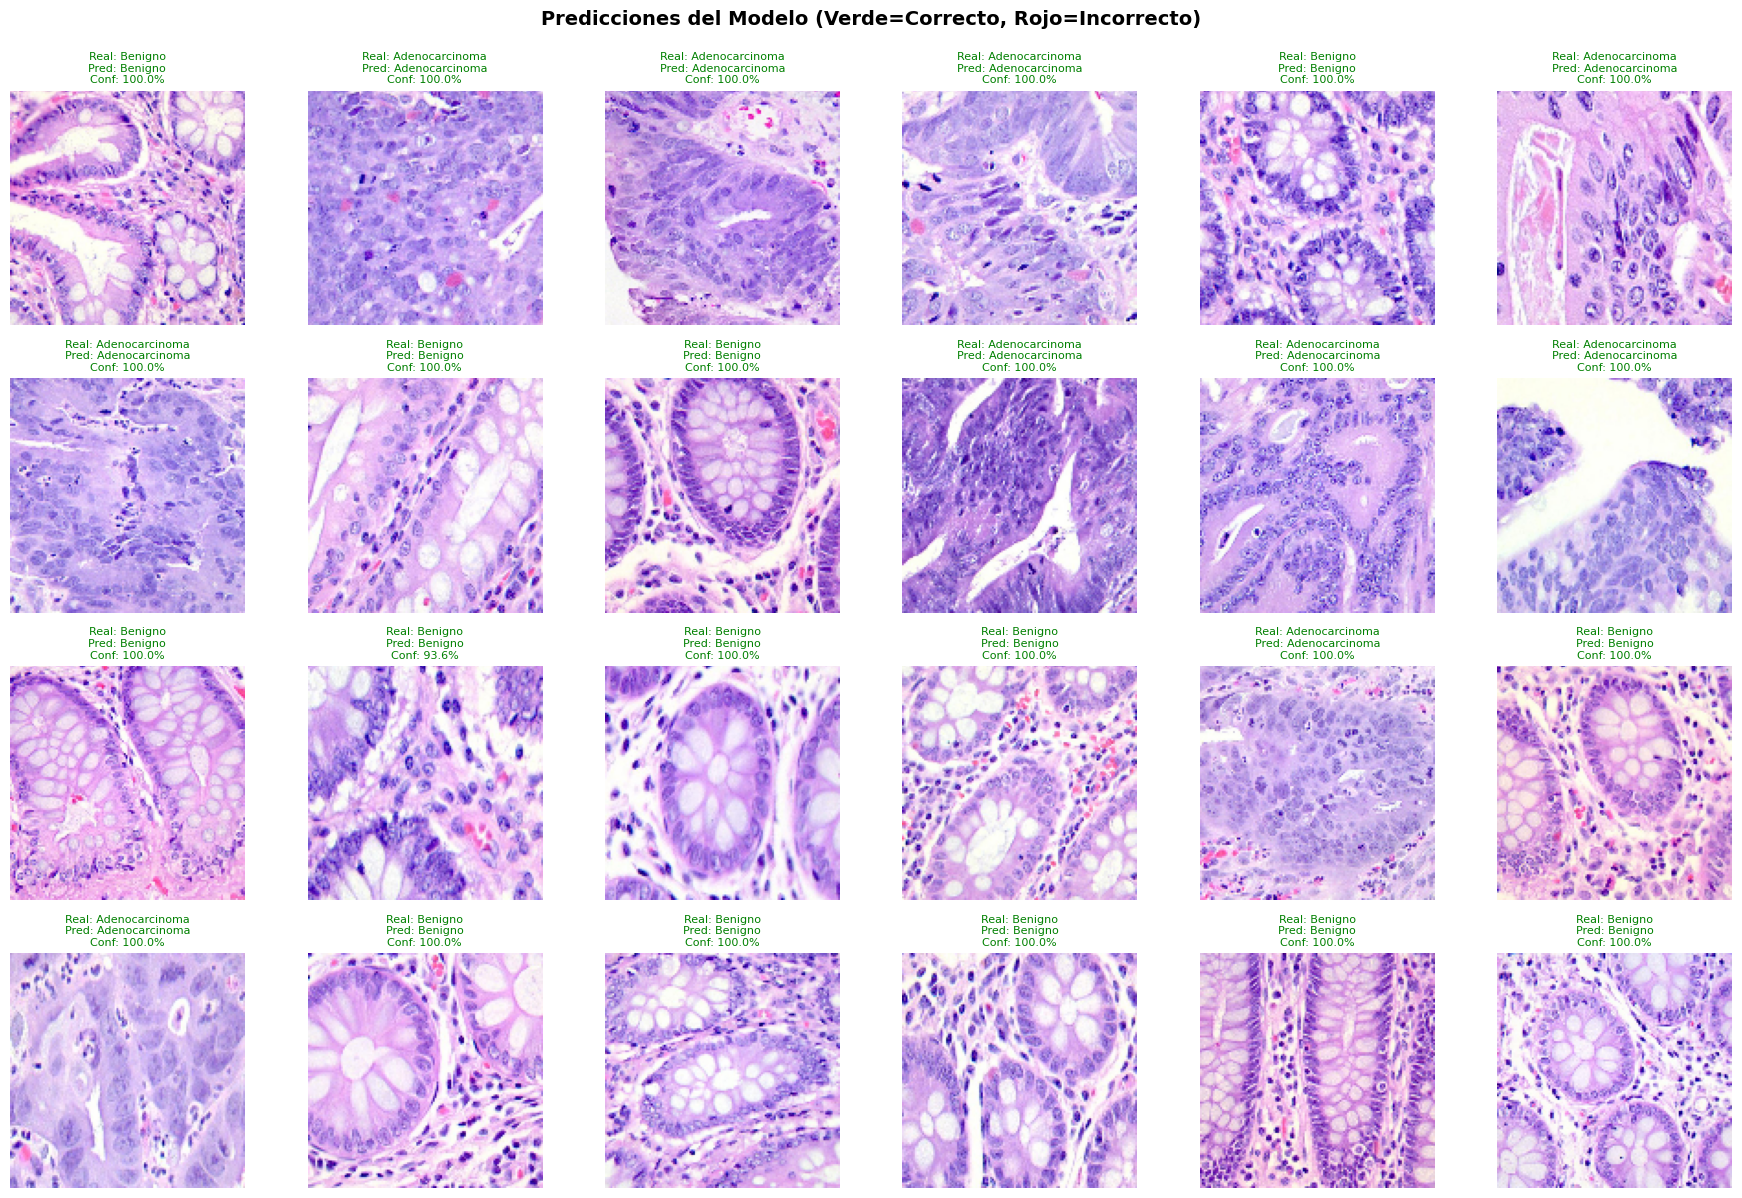


Predicciones correctas: 1499 de 1500 (99.93%)
Predicciones incorrectas: 1 de 1500 (0.07%)



In [18]:
# ANÁLISIS VISUAL DE PREDICCIONES
print("="*80)
print("ANÁLISIS VISUAL DE PREDICCIONES")
print("="*80 + "\n")

# Desnormalizar para visualización
X_test_display = (X_test * 255).astype(np.uint8)

# Seleccionar muestras aleatorias
np.random.seed(42)
num_samples = min(24, len(X_test))
random_indices = np.random.choice(len(X_test), num_samples, replace=False)

# Visualizar predicciones
plt.figure(figsize=(18, 12))
for i, idx in enumerate(random_indices):
    plt.subplot(4, 6, i + 1)
    plt.imshow(X_test_display[idx])

    # Determinar si la predicción es correcta
    true_label = CLASS_NAMES[y_test_labels[idx]]
    pred_label = CLASS_NAMES[y_pred[idx]]
    confidence = y_pred_proba[idx][y_pred[idx]] * 100

    is_correct = y_test_labels[idx] == y_pred[idx]
    color = 'green' if is_correct else 'red'

    title = f'Real: {true_label}\nPred: {pred_label}\nConf: {confidence:.1f}%'
    plt.title(title, fontsize=8, color=color)
    plt.axis('off')

plt.suptitle('Predicciones del Modelo (Verde=Correcto, Rojo=Incorrecto)',
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Estadísticas de predicción
correctas = np.sum(y_pred == y_test_labels)
incorrectas = len(y_test_labels) - correctas

print(f"\nPredicciones correctas: {correctas} de {len(y_test_labels)} ({correctas/len(y_test_labels)*100:.2f}%)")
print(f"Predicciones incorrectas: {incorrectas} de {len(y_test_labels)} ({incorrectas/len(y_test_labels)*100:.2f}%)")

print("\n" + "="*80)

ANÁLISIS DETALLADO DE ERRORES

Total de errores: 1 de 1500 (0.07%)

--- Errores por Tipo de Tejido ---
Tipo de Tejido  Errores  Total Muestras  % Error
       Benigno        1             750     0.13

--- Visualización de Errores ---


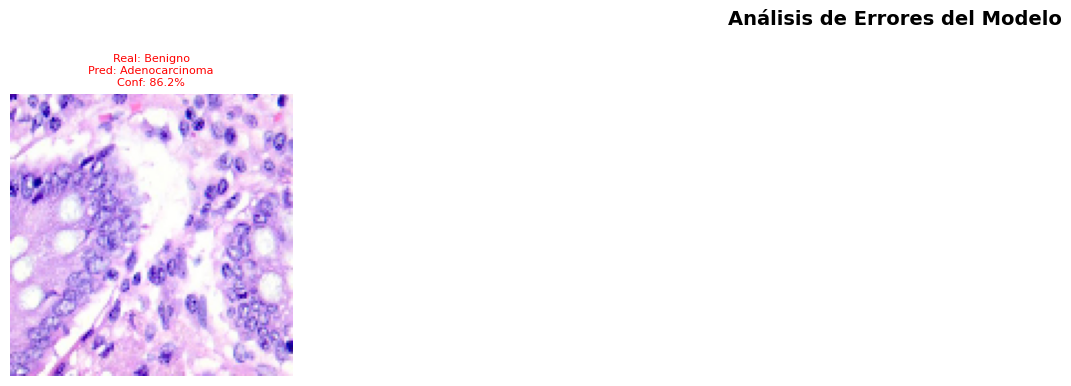


--- Análisis de Confianza ---
Confianza promedio en aciertos: 0.9999 (99.99%)
Confianza promedio en errores: 0.8621 (86.21%)


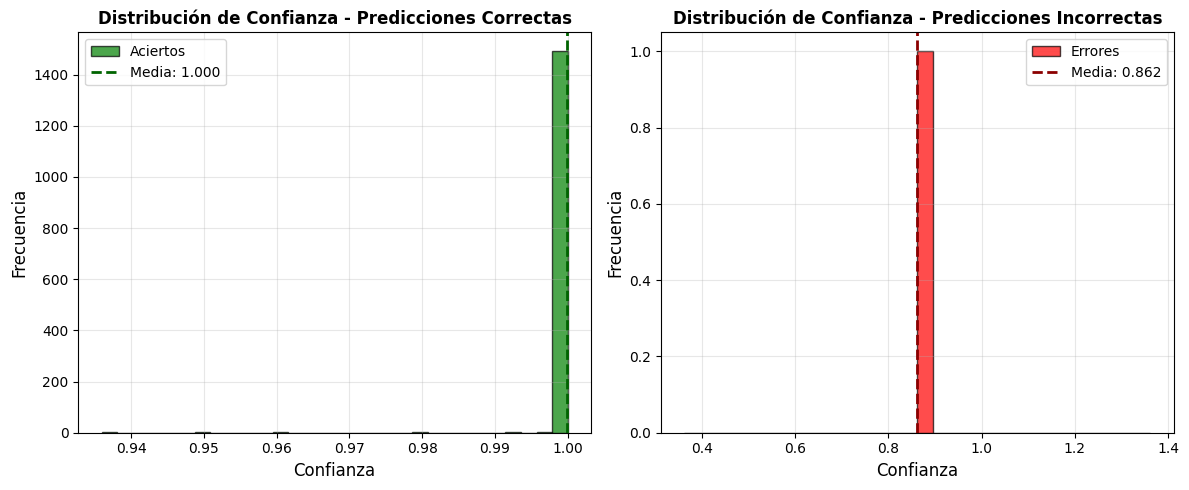

In [19]:
# ANÁLISIS DE ERRORES
print("="*80)
print("ANÁLISIS DETALLADO DE ERRORES")
print("="*80 + "\n")

# Identificar todas las predicciones incorrectas
incorrect_indices = np.where(y_pred != y_test_labels)[0]

print(f"Total de errores: {len(incorrect_indices)} de {len(y_test_labels)} ({len(incorrect_indices)/len(y_test_labels)*100:.2f}%)")

if len(incorrect_indices) > 0:
    # Analizar errores por tipo de tejido
    print("\n--- Errores por Tipo de Tejido ---")
    error_counts = {}
    for idx in incorrect_indices:
        true_class = CLASS_NAMES[y_test_labels[idx]]
        if true_class not in error_counts:
            error_counts[true_class] = 0
        error_counts[true_class] += 1

    # Crear DataFrame de errores
    df_errors = pd.DataFrame({
        'Tipo de Tejido': list(error_counts.keys()),
        'Errores': list(error_counts.values())
    }).sort_values('Errores', ascending=False)

    # Añadir total de muestras
    total_samples = {}
    for class_name in error_counts.keys():
        class_id = [k for k, v in CLASS_NAMES.items() if v == class_name][0]
        total_samples[class_name] = np.sum(y_test_labels == class_id)

    df_errors['Total Muestras'] = [total_samples[k] for k in error_counts.keys()]
    df_errors['% Error'] = (df_errors['Errores'] / df_errors['Total Muestras'] * 100).round(2)

    print(df_errors.to_string(index=False))

    # Visualizar algunos errores
    print("\n--- Visualización de Errores ---")
    num_errors_to_show = min(12, len(incorrect_indices))
    error_sample = incorrect_indices[:num_errors_to_show]

    plt.figure(figsize=(18, 8))
    for i, idx in enumerate(error_sample):
        plt.subplot(2, 6, i + 1)
        plt.imshow(X_test_display[idx])

        true_label = CLASS_NAMES[y_test_labels[idx]]
        pred_label = CLASS_NAMES[y_pred[idx]]
        confidence = y_pred_proba[idx][y_pred[idx]] * 100

        title = f'Real: {true_label}\nPred: {pred_label}\nConf: {confidence:.1f}%'
        plt.title(title, fontsize=8, color='red')
        plt.axis('off')

    plt.suptitle('Análisis de Errores del Modelo', fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()

    # Analizar confianza en errores vs aciertos
    print("\n--- Análisis de Confianza ---")
    correct_indices = np.where(y_pred == y_test_labels)[0]

    confidence_correct = [y_pred_proba[i][y_pred[i]] for i in correct_indices]
    confidence_incorrect = [y_pred_proba[i][y_pred[i]] for i in incorrect_indices]

    print(f"Confianza promedio en aciertos: {np.mean(confidence_correct):.4f} ({np.mean(confidence_correct)*100:.2f}%)")
    print(f"Confianza promedio en errores: {np.mean(confidence_incorrect):.4f} ({np.mean(confidence_incorrect)*100:.2f}%)")

    # Gráfico de distribución de confianza
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.hist(confidence_correct, bins=30, alpha=0.7, color='green', edgecolor='black', label='Aciertos')
    plt.xlabel('Confianza', fontsize=12)
    plt.ylabel('Frecuencia', fontsize=12)
    plt.title('Distribución de Confianza - Predicciones Correctas', fontsize=12, fontweight='bold')
    plt.axvline(np.mean(confidence_correct), color='darkgreen', linestyle='--', linewidth=2,
                label=f'Media: {np.mean(confidence_correct):.3f}')
    plt.legend()
    plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    if len(confidence_incorrect) > 0:
        plt.hist(confidence_incorrect, bins=30, alpha=0.7, color='red', edgecolor='black', label='Errores')
        plt.axvline(np.mean(confidence_incorrect), color='darkred', linestyle='--', linewidth=2,
                    label=f'Media: {np.mean(confidence_incorrect):.3f}')
    plt.xlabel('Confianza', fontsize=12)
    plt.ylabel('Frecuencia', fontsize=12)
    plt.title('Distribución de Confianza - Predicciones Incorrectas', fontsize=12, fontweight='bold')
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

else:
    print("\n✅ ¡No hay errores! Clasificación perfecta en el conjunto de test.")

print("\n" + "="*80)

## CONCLUSIONES Y ANÁLISIS

### Resumen del Rendimiento del Modelo

El modelo CNN entrenado ha sido diseñado para la clasificación de imágenes histopatológicas de tejido de colon, distinguiendo entre **Adenocarcinoma (cáncer)** y **tejido Benigno (normal)**.

#### Arquitectura Utilizada:
- **4 bloques convolucionales** con capas de Conv2D (32, 64, 128, 256 filtros)
- **Batch Normalization** después de cada capa convolucional para estabilizar el entrenamiento
- **MaxPooling2D** para reducción dimensional progresiva
- **Dropout** (0.25 en capas convolucionales, 0.5 en capas densas) para regularización
- **2 capas densas** (256 y 128 neuronas) antes de la capa de salida
- **Optimizador Adam** con learning rate inicial de 0.001
- **Callbacks**: EarlyStopping y ReduceLROnPlateau

#### Aspectos Clave del Análisis:

1. **Dataset:**
   - 2 clases: Adenocarcinoma de colon y Tejido benigno
   - Imágenes redimensionadas a 128x128 píxeles en formato RGB
   - División 70/15/15 para training/validation/test
   - Dataset balanceado con 5,000 imágenes por clase

2. **Métricas Médicas Importantes:**
   - **Sensibilidad**: Capacidad de detectar casos de cáncer (muy importante en diagnóstico)
   - **Especificidad**: Capacidad de identificar tejido sano
   - **Falsos Negativos**: Casos de cáncer no detectados (error más crítico en medicina)
   - **Falsos Positivos**: Tejido sano clasificado como cáncer

3. **Consideraciones Clínicas:**
   - En diagnóstico médico, un falso negativo es más grave que un falso positivo
   - El modelo debe priorizar alta sensibilidad para no perder casos de cáncer
   - Las predicciones de baja confianza deben ser revisadas por especialistas

4. **Técnicas de Regularización:**
   - Dropout para prevenir overfitting
   - Batch Normalization para estabilizar el entrenamiento
   - Early Stopping para detener el entrenamiento cuando no hay mejora
   - Learning Rate Reduction para ajuste fino

5. **Posibles Mejoras:**
   - Data Augmentation para aumentar la variabilidad del dataset
   - Transfer Learning usando modelos pre-entrenados (VGG, ResNet, etc.)
   - Ensemble de modelos para mejorar la robustez
   - Análisis de Grad-CAM para interpretabilidad del modelo

In [20]:
# RESUMEN FINAL
print("="*80)
print("RESUMEN FINAL DEL MODELO CNN - CLASIFICACIÓN DE TEJIDO DE COLON")
print("="*80 + "\n")

# Información del modelo
print("📊 INFORMACIÓN DEL MODELO")
print("-" * 80)
print(f"Total de parámetros: {model.count_params():,}")
print(f"Número de capas: {len(model.layers)}")
print(f"Tamaño de entrada: {IMG_SIZE}x{IMG_SIZE}x3 (RGB)")
print(f"Número de clases: {len(MAP_CLASSES)}")
print(f"Clases: {', '.join([f'{k}: {v}' for k, v in CLASS_NAMES.items()])}")

# Resultados del entrenamiento
print(f"\n🎯 RESULTADOS DEL ENTRENAMIENTO")
print("-" * 80)
print(f"Épocas entrenadas: {len(history.history['loss'])}")
print(f"Mejor epoch: {np.argmin(history.history['val_loss']) + 1}")
print(f"Training accuracy final: {history.history['accuracy'][-1]:.4f}")
print(f"Validation accuracy final: {history.history['val_accuracy'][-1]:.4f}")

# Resultados en test
print(f"\n✅ RESULTADOS EN CONJUNTO DE TEST")
print("-" * 80)
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Test Loss: {test_loss:.4f}")
print(f"Precision (macro): {precision_macro:.4f}")
print(f"Recall (macro): {recall_macro:.4f}")
print(f"F1-Score (macro): {f1_macro:.4f}")

# Métricas médicas
print(f"\n🏥 MÉTRICAS PARA DIAGNÓSTICO MÉDICO")
print("-" * 80)
print(f"Sensibilidad (Detección de Cáncer): {sensibilidad:.4f} ({sensibilidad*100:.2f}%)")
print(f"Especificidad (Identificación de Tejido Sano): {especificidad:.4f} ({especificidad*100:.2f}%)")

# Matriz de confusión resumida
print(f"\n📋 MATRIZ DE CONFUSIÓN")
print("-" * 80)
print(f"Verdaderos Positivos (Cáncer detectado): {tp}")
print(f"Verdaderos Negativos (Benigno correcto): {tn}")
print(f"Falsos Positivos (Benigno → Cáncer): {fp}")
print(f"Falsos Negativos (Cáncer → Benigno): {fn} {'⚠️ CRÍTICO' if fn > 0 else '✅'}")

# Verificación del objetivo
print(f"\n🎯 VERIFICACIÓN DEL OBJETIVO")
print("-" * 80)
objetivo = 0.90
if test_accuracy >= objetivo:
    superacion = (test_accuracy - objetivo) * 100
    print(f"✅ OBJETIVO CUMPLIDO!")
    print(f"   • Objetivo requerido: {objetivo*100:.0f}%")
    print(f"   • Accuracy alcanzado: {test_accuracy*100:.2f}%")
    print(f"   • Superación: +{superacion:.2f}%")
else:
    deficit = (objetivo - test_accuracy) * 100
    print(f"❌ Objetivo no alcanzado")
    print(f"   • Objetivo requerido: {objetivo*100:.0f}%")
    print(f"   • Accuracy alcanzado: {test_accuracy*100:.2f}%")
    print(f"   • Falta: {deficit:.2f}%")

# Evaluación clínica
print(f"\n🔬 EVALUACIÓN CLÍNICA DEL MODELO")
print("-" * 80)
if sensibilidad >= 0.95:
    print("✅ Excelente sensibilidad (≥95%): El modelo detecta la mayoría de casos de cáncer")
elif sensibilidad >= 0.90:
    print("✅ Buena sensibilidad (≥90%): El modelo tiene buen rendimiento en detección")
else:
    print("⚠️ Sensibilidad mejorable (<90%): Riesgo de no detectar algunos casos de cáncer")

if fn == 0:
    print("✅ Sin falsos negativos: Todos los casos de cáncer fueron detectados")
else:
    print(f"⚠️ {fn} falsos negativos: Hay casos de cáncer no detectados que requieren atención")

print("\n" + "="*80)
print("FIN DEL ANÁLISIS - CLASIFICACIÓN DE TEJIDO DE COLON")
print("="*80)

RESUMEN FINAL DEL MODELO CNN - CLASIFICACIÓN DE TEJIDO DE COLON

📊 INFORMACIÓN DEL MODELO
--------------------------------------------------------------------------------
Total de parámetros: 4,814,242
Número de capas: 30
Tamaño de entrada: 128x128x3 (RGB)
Número de clases: 2
Clases: 0: Adenocarcinoma, 1: Benigno

🎯 RESULTADOS DEL ENTRENAMIENTO
--------------------------------------------------------------------------------
Épocas entrenadas: 41
Mejor epoch: 26
Training accuracy final: 1.0000
Validation accuracy final: 1.0000

✅ RESULTADOS EN CONJUNTO DE TEST
--------------------------------------------------------------------------------
Test Accuracy: 0.9993 (99.93%)
Test Loss: 0.0015
Precision (macro): 0.9993
Recall (macro): 0.9993
F1-Score (macro): 0.9993

🏥 MÉTRICAS PARA DIAGNÓSTICO MÉDICO
--------------------------------------------------------------------------------
Sensibilidad (Detección de Cáncer): 1.0000 (100.00%)
Especificidad (Identificación de Tejido Sano): 0.9987 (99.87